# Factor-Based Return Attribution using Fama-French Multi-Factor Regression on NSE Stocks

## Overview
This project applies the Fama-French multi-factor framework to eight NSE large-cap stocks, moving from a CAPM single-factor baseline through the three-factor (Market, SMB, HML) model to a five-factor comparison. The goal is to attribute realized stock returns to systematic risk exposure versus stock-specific alpha, and to test whether the standard OLS assumptions actually hold for Indian equity return data.

**Universe:** Reliance, HDFC Bank, Infosys, Sun Pharma, Tata Steel, Maruti Suzuki, ITC, Bharti Airtel
**Period:** January 2015 – December 2025 (monthly)
**Data Source:** Yahoo Finance (yfinance)

## Project Structure
1. Data Collection and Preparation
2. Factor Construction (Market, SMB, HML)
3. CAPM Baseline Regression
4. Fama-French 3-Factor Model
5. Regression Assumption Testing (VIF, White, Durbin-Watson, Jarque-Bera, Newey-West)
6. Rolling Window Regression
7. CAPM vs FF3 vs FF5 Model Comparison
8. Final Dashboard

In [1]:
# Cell 1 — Phase 1: Data Collection and Preparation | Import Libraries & Setup

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print("Environment ready")

Environment ready


In [2]:
# Cell 2 — Phase 1: Data Collection and Preparation | Define Universe & Download Price Data
# NSE tickers carry a .NS suffix on Yahoo Finance

tickers = {
    'RELIANCE.NS': 'Reliance',
    'HDFCBANK.NS': 'HDFC Bank',
    'INFY.NS': 'Infosys',
    'SUNPHARMA.NS': 'Sun Pharma',
    'TATASTEEL.NS': 'Tata Steel',
    'MARUTI.NS': 'Maruti Suzuki',
    'ITC.NS': 'ITC',
    'BHARTIARTL.NS': 'Bharti Airtel'
}

start_date = '2015-01-01'
end_date = '2026-01-01'  # yfinance end date is exclusive, so this pulls all of Dec 2024

raw_data = yf.download(list(tickers.keys()), start=start_date, end=end_date, auto_adjust=True, progress=False)

print(raw_data.shape)
raw_data.head()

(2716, 40)


Price              Close                                                      \
Ticker     BHARTIARTL.NS HDFCBANK.NS  INFY.NS   ITC.NS MARUTI.NS RELIANCE.NS   
Date                                                                           
2015-01-01      308.0735    213.7008 359.9810 156.9481 3032.0349    189.1254   
2015-01-02      309.8987    216.6750 367.0552 157.4396 3049.1436    188.6248   
2015-01-05      303.0224    214.8456 363.9011 158.0595 3129.1929    186.5587   
2015-01-06      300.6455    211.5011 356.2981 153.9985 3081.4985    178.0918   
2015-01-07      301.3671    212.1184 358.0029 151.1344 3120.0718    181.9685   

Price                                         High              ...  \
Ticker     SUNPHARMA.NS TATASTEEL.NS BHARTIARTL.NS HDFCBANK.NS  ...   
Date                                                            ...   
2015-01-01     750.9713      28.3141      309.7714    214.2283  ...   
2015-01-02     754.6705      28.7551      311.5541    217.5728  ...   
2015-01-05     755.1271      29.1717      310.9174    217.8534  ...   
2015-01-06     738.5038      27.7576      302.3009    214.7110  ...   
2015-01-07     739.6455      27.2255      303.9139    213.5437  ...   

Price              Open                     Volume                       \
Ticker     SUNPHARMA.NS TATASTEEL.NS BHARTIARTL.NS HDFCBANK.NS  INFY.NS   
Date                                                                      
2015-01-01     754.8988      27.7996       2460188     3544940  2002764   
2015-01-02     752.6154      28.4226       2795887     5900384  6778320   
2015-01-05     754.5334      28.9127       1605267     4796000  9937024   
2015-01-06     751.7020      28.9827       3916948     8219680  9667316   
2015-01-07     739.0061      27.8486       4899318     5746112  7249916   

Price                                                                 
Ticker        ITC.NS MARUTI.NS RELIANCE.NS SUNPHARMA.NS TATASTEEL.NS  
Date                                                                  
2015-01-01   2636761    299232     2963643       587479     26570816  
2015-01-02   6853849    233924     7331366       710310     36043328  
2015-01-05   8556295    536747    10103941       792287     54638866  
2015-01-06  13597291    422743    18627980      1709888     64767961  
2015-01-07  12421217    369241    20720312      1730518     49846923  

[5 rows x 40 columns]

In [3]:
# Cell 3 — Phase 1: Data Collection and Preparation | Extract Close Prices & Rename Columns

close_prices = raw_data['Close'].copy()
close_prices = close_prices.rename(columns=tickers)
close_prices = close_prices[list(tickers.values())]  # reorder to match our original stock order

print(close_prices.shape)
close_prices.head()

(2716, 8)


Ticker,Reliance,HDFC Bank,Infosys,Sun Pharma,Tata Steel,Maruti Suzuki,ITC,Bharti Airtel
Date,,,,,,,,
2015-01-01,189.1254,213.7008,359.9810,750.9713,28.3141,3032.0349,156.9481,308.0735
2015-01-02,188.6248,216.6750,367.0552,754.6705,28.7551,3049.1436,157.4396,309.8987
2015-01-05,186.5587,214.8456,363.9011,755.1271,29.1717,3129.1929,158.0595,303.0224
2015-01-06,178.0918,211.5011,356.2981,738.5038,27.7576,3081.4985,153.9985,300.6455
2015-01-07,181.9685,212.1184,358.0029,739.6455,27.2255,3120.0718,151.1344,301.3671


In [4]:
# Cell 4 — Phase 1: Data Collection and Preparation | Check for Missing Values

print(close_prices.isnull().sum())
print("\nTotal missing values:", close_prices.isnull().sum().sum())
print("\nDate range:", close_prices.index.min().date(), "to", close_prices.index.max().date())
print("Trading days:", len(close_prices))

Ticker
Reliance         0
HDFC Bank        0
Infosys          0
Sun Pharma       0
Tata Steel       0
Maruti Suzuki    0
ITC              0
Bharti Airtel    0
dtype: int64

Total missing values: 0

Date range: 2015-01-01 to 2025-12-31
Trading days: 2716


In [5]:
# Cell 5 — Phase 1: Data Collection and Preparation | Resample to Monthly & Compute Returns

monthly_prices = close_prices.resample('ME').last()
monthly_returns = monthly_prices.pct_change().dropna()

print("Monthly prices shape:", monthly_prices.shape)
print("Monthly returns shape:", monthly_returns.shape)
monthly_returns.head()

Monthly prices shape: (132, 8)
Monthly returns shape: (131, 8)


Ticker,Reliance,HDFC Bank,Infosys,Sun Pharma,Tata Steel,Maruti Suzuki,ITC,Bharti Airtel
Date,,,,,,,,
2015-02-28,-0.0652,-0.0217,0.0578,-0.0423,-0.1019,-0.0118,0.0682,-0.0495
2015-03-31,-0.0345,-0.0297,-0.0209,0.1650,-0.0967,0.0258,-0.1723,0.1073
2015-04-30,0.0440,-0.0331,-0.1245,-0.0831,0.1376,0.0077,-0.0107,-0.0310
2015-05-31,0.0298,0.0624,0.0417,0.0290,-0.0884,0.0161,0.0147,0.1168
2015-06-30,0.1404,0.0158,-0.0122,-0.0947,-0.0728,0.0628,-0.0165,-0.0130


,Ann. Mean Return,Ann. Volatility,Skewness,Excess Kurtosis,Min (Monthly),Max (Monthly)
Ticker,,,,,,
Reliance,0.2262,0.2676,0.6896,1.3593,-0.1617,0.3163
HDFC Bank,0.1496,0.2052,-0.3460,3.8619,-0.2681,0.2174
Infosys,0.1571,0.2414,0.4219,2.0771,-0.1779,0.3126
Sun Pharma,0.1040,0.2817,0.3039,0.8883,-0.2186,0.3183
Tata Steel,0.2363,0.3635,0.2720,1.1248,-0.2938,0.4063
Maruti Suzuki,0.1884,0.2768,-0.6160,2.3236,-0.3175,0.2496
ITC,0.1042,0.2121,-0.0120,0.6437,-0.1723,0.1719
Bharti Airtel,0.2060,0.2526,0.0014,1.1067,-0.1796,0.2767


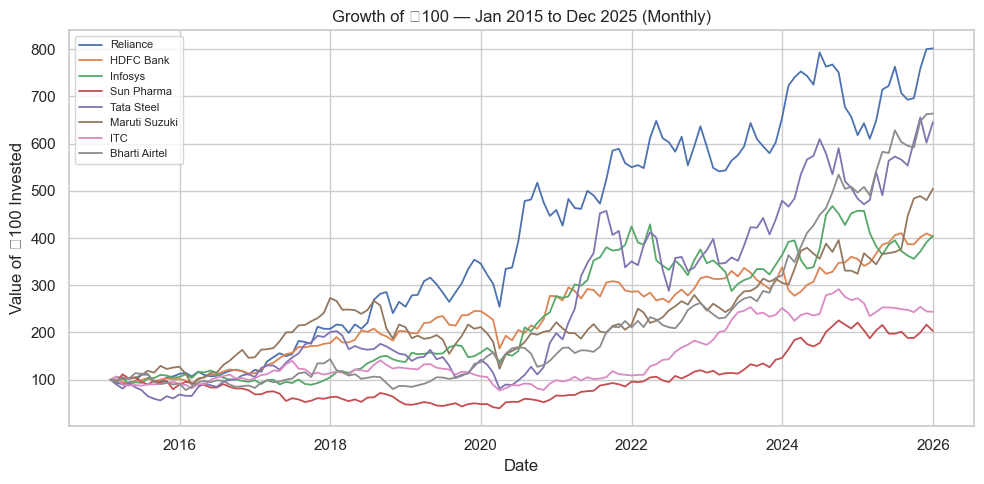

In [6]:
# Cell 6 — Phase 1: Data Collection and Preparation | Summary Statistics & Sanity Check

from IPython.display import display

summary_stats = pd.DataFrame({
    'Ann. Mean Return': monthly_returns.mean() * 12,
    'Ann. Volatility': monthly_returns.std() * np.sqrt(12),
    'Skewness': monthly_returns.skew(),
    'Excess Kurtosis': monthly_returns.kurt(),
    'Min (Monthly)': monthly_returns.min(),
    'Max (Monthly)': monthly_returns.max()
})
display(summary_stats)

growth = monthly_prices / monthly_prices.iloc[0] * 100

plt.figure(figsize=(10, 5))
for stock in growth.columns:
    plt.plot(growth.index, growth[stock], label=stock, linewidth=1.3)
plt.title('Growth of ₹100 — Jan 2015 to Dec 2025 (Monthly)')
plt.xlabel('Date')
plt.ylabel('Value of ₹100 Invested')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# phase 2

In [7]:
# Cell 7 — Phase 2: Factor Construction | Load IIMA Factor Data

factor_file = '2025-12_FourFactors_and_Market_Returns_Monthly_SurvivorshipBiasAdjusted.csv'

factors_raw = pd.read_csv(factor_file, na_values=['NA'])
factors_raw['Date'] = pd.to_datetime(factors_raw['Date'], format='%Y-%m') + pd.offsets.MonthEnd(0)
factors_raw = factors_raw.set_index('Date')

print(factors_raw.shape)
print(factors_raw.isnull().sum())
factors_raw.tail()

(387, 5)
SMB    1
HML    1
WML    1
MF     1
RF     1
dtype: int64


,SMB,HML,WML,MF,RF
Date,,,,,
2025-08-31,-1.5922,-2.3819,0.5409,-1.8000,0.4232
2025-09-30,-2.8250,3.4737,-2.7506,0.5306,0.4701
2025-10-31,-2.1472,1.5348,1.8486,2.8881,0.4516
2025-11-30,-3.6742,-1.7667,4.9391,-1.0032,0.4057
2025-12-31,-3.6219,1.8529,1.3014,-0.7207,0.4677


In [8]:
# Cell 8 — Phase 2: Factor Construction | Filter to Study Window & Convert to Decimal

factors = factors_raw.loc['2015-02':'2025-12'] / 100

print(factors.shape)
print(factors.isnull().sum())
factors.head()

(131, 5)
SMB    0
HML    0
WML    0
MF     0
RF     0
dtype: int64


,SMB,HML,WML,MF,RF
Date,,,,,
2015-02-28,-0.0031,0.0010,0.0101,0.0053,0.0063
2015-03-31,0.0025,-0.0595,0.0862,-0.0243,0.0068
2015-04-30,0.0174,0.0299,-0.0553,-0.0363,0.0063
2015-05-31,0.0059,-0.0425,0.0348,0.0309,0.0061
2015-06-30,-0.0177,-0.0090,0.0369,-0.0166,0.0065


In [9]:
# Cell 9 — Phase 2: Factor Construction | Merge Stock Returns with Factors & Compute Excess Returns

# Confirm both datasets share the exact same date index before merging
assert monthly_returns.index.equals(factors.index), "Date mismatch between stock returns and factor data"

excess_returns = monthly_returns.sub(factors['RF'], axis=0)

print(excess_returns.shape)
excess_returns.head()

(131, 8)


Ticker,Reliance,HDFC Bank,Infosys,Sun Pharma,Tata Steel,Maruti Suzuki,ITC,Bharti Airtel
Date,,,,,,,,
2015-02-28,-0.0716,-0.0280,0.0515,-0.0487,-0.1083,-0.0181,0.0619,-0.0558
2015-03-31,-0.0413,-0.0365,-0.0277,0.1582,-0.1035,0.0190,-0.1791,0.1005
2015-04-30,0.0377,-0.0394,-0.1308,-0.0894,0.1313,0.0014,-0.0170,-0.0373
2015-05-31,0.0237,0.0564,0.0356,0.0229,-0.0945,0.0100,0.0087,0.1107
2015-06-30,0.1338,0.0093,-0.0187,-0.1012,-0.0793,0.0562,-0.0230,-0.0196


,Ann. Mean,Ann. Volatility,Skewness,Excess Kurtosis,Min (Monthly),Max (Monthly)
MF,0.0867,0.1596,-0.5836,1.9289,-0.1881,0.1388
SMB,-0.0065,0.1452,-0.1444,0.5893,-0.1409,0.0922
HML,0.1060,0.1584,0.2971,0.0908,-0.0968,0.1361



Factor Correlation Matrix:


,MF,SMB,HML
MF,1.0000,0.3681,0.4796
SMB,0.3681,1.0000,0.2589
HML,0.4796,0.2589,1.0000


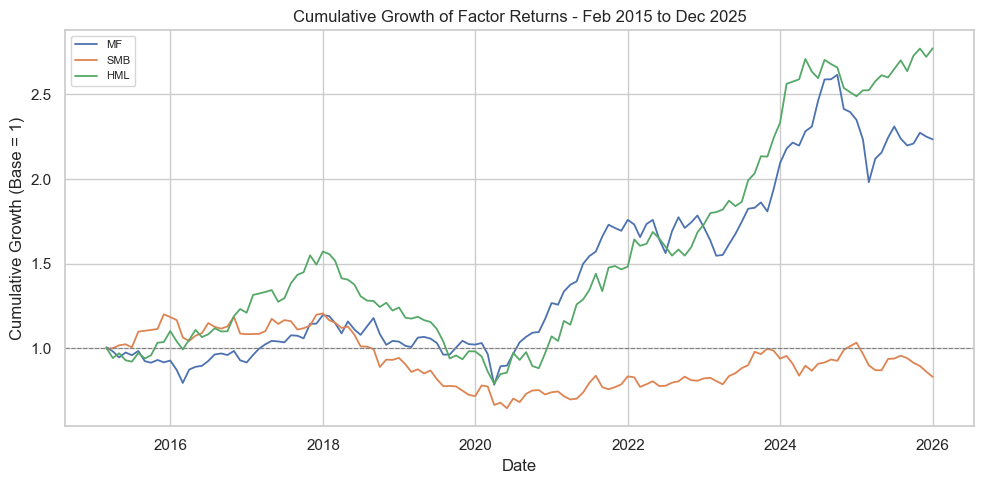

In [10]:
# Cell 10 — Phase 2: Factor Construction | Factor Summary Statistics & Correlation Check

factor_cols = ['MF', 'SMB', 'HML']

factor_stats = pd.DataFrame({
    'Ann. Mean': factors[factor_cols].mean() * 12,
    'Ann. Volatility': factors[factor_cols].std() * np.sqrt(12),
    'Skewness': factors[factor_cols].skew(),
    'Excess Kurtosis': factors[factor_cols].kurt(),
    'Min (Monthly)': factors[factor_cols].min(),
    'Max (Monthly)': factors[factor_cols].max()
})
display(factor_stats)

print("\nFactor Correlation Matrix:")
display(factors[factor_cols].corr())

cumulative_factors = (1 + factors[factor_cols]).cumprod()

plt.figure(figsize=(10, 5))
for col in factor_cols:
    plt.plot(cumulative_factors.index, cumulative_factors[col], label=col, linewidth=1.3)
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8)
plt.title('Cumulative Growth of Factor Returns - Feb 2015 to Dec 2025')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth (Base = 1)')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [11]:
# Cell 11 — Phase 3: CAPM Baseline Regression | Run CAPM for All Stocks

capm_models = {}
capm_results = []

X = sm.add_constant(factors['MF'])

for stock in excess_returns.columns:
    y = excess_returns[stock]
    model = sm.OLS(y, X).fit()
    capm_models[stock] = model

    capm_results.append({
        'Stock': stock,
        'Alpha (Monthly)': model.params['const'],
        'Alpha (Annualized)': model.params['const'] * 12,
        'Alpha t-stat': model.tvalues['const'],
        'Alpha p-value': model.pvalues['const'],
        'Beta': model.params['MF'],
        'Beta t-stat': model.tvalues['MF'],
        'Beta p-value': model.pvalues['MF'],
        'R-squared': model.rsquared
    })

capm_summary = pd.DataFrame(capm_results).set_index('Stock')
display(capm_summary.round(4))

,Alpha (Monthly),Alpha (Annualized),Alpha t-stat,Alpha p-value,Beta,Beta t-stat,Beta p-value,R-squared
Stock,,,,,,,,
Reliance,0.0064,0.0773,1.2104,0.2283,1.0623,9.2763,0.0000,0.4001
HDFC Bank,0.0022,0.0268,0.5250,0.6005,0.7603,8.3023,0.0000,0.3482
Infosys,0.0038,0.0460,0.6788,0.4985,0.6252,5.1437,0.0000,0.1702
Sun Pharma,-0.0015,-0.0181,-0.2298,0.8186,0.7519,5.3324,0.0000,0.1806
Tata Steel,0.0060,0.0720,0.7651,0.4456,1.2391,7.3372,0.0000,0.2944
Maruti Suzuki,0.0043,0.0520,0.7197,0.4730,0.9171,7.0707,0.0000,0.2793
ITC,-0.0012,-0.0144,-0.2620,0.7937,0.7130,7.2083,0.0000,0.2871
Bharti Airtel,0.0067,0.0799,1.1896,0.2364,0.7996,6.6403,0.0000,0.2547


# phase 3

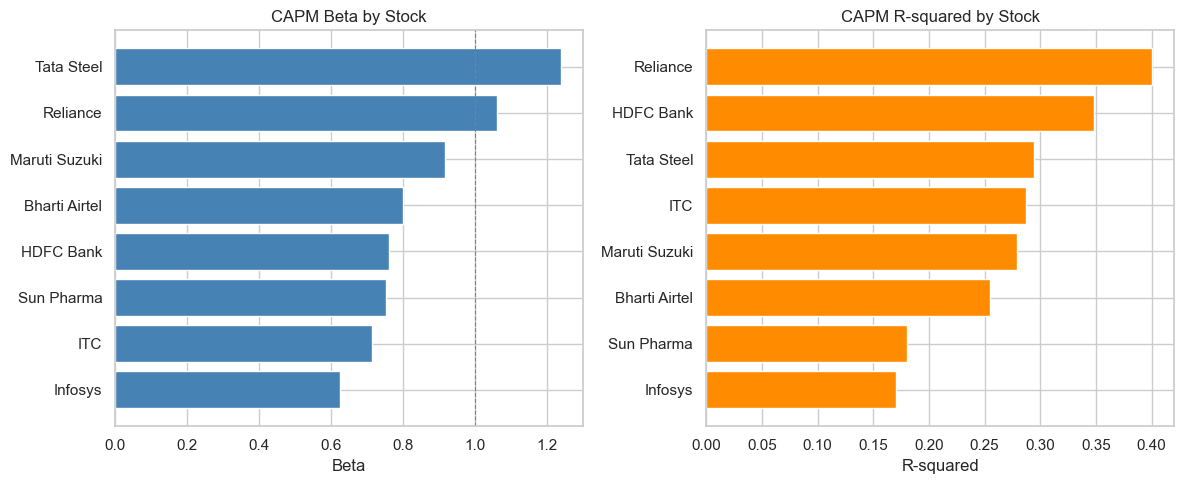

Average Beta across portfolio: 0.8586
Average R-squared across portfolio: 0.2769

Highest Beta: Tata Steel (1.2391)
Lowest Beta: Infosys (0.6252)


In [12]:
# Cell 12 — Phase 3: CAPM Baseline Regression | Beta & R-squared Visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sorted_beta = capm_summary['Beta'].sort_values()
axes[0].barh(sorted_beta.index, sorted_beta.values, color='steelblue')
axes[0].axvline(1, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('CAPM Beta by Stock')
axes[0].set_xlabel('Beta')

sorted_r2 = capm_summary['R-squared'].sort_values()
axes[1].barh(sorted_r2.index, sorted_r2.values, color='darkorange')
axes[1].set_title('CAPM R-squared by Stock')
axes[1].set_xlabel('R-squared')

plt.tight_layout()
plt.show()

print(f"Average Beta across portfolio: {capm_summary['Beta'].mean():.4f}")
print(f"Average R-squared across portfolio: {capm_summary['R-squared'].mean():.4f}")
print(f"\nHighest Beta: {capm_summary['Beta'].idxmax()} ({capm_summary['Beta'].max():.4f})")
print(f"Lowest Beta: {capm_summary['Beta'].idxmin()} ({capm_summary['Beta'].min():.4f})")

# phase 4


In [13]:
# Cell 13 — Phase 4: Fama-French 3-Factor Model | Run FF3 for All Stocks

ff3_models = {}
ff3_results = []

X = sm.add_constant(factors[['MF', 'SMB', 'HML']])

for stock in excess_returns.columns:
    y = excess_returns[stock]
    model = sm.OLS(y, X).fit()
    ff3_models[stock] = model

    ff3_results.append({
        'Stock': stock,
        'Alpha (Monthly)': model.params['const'],
        'Alpha (Annualized)': model.params['const'] * 12,
        'Alpha p-value': model.pvalues['const'],
        'Beta (Mkt)': model.params['MF'],
        'Beta (SMB)': model.params['SMB'],
        'Beta (HML)': model.params['HML'],
        'SMB p-value': model.pvalues['SMB'],
        'HML p-value': model.pvalues['HML'],
        'R-squared': model.rsquared,
        'Adj. R-squared': model.rsquared_adj
    })

ff3_summary = pd.DataFrame(ff3_results).set_index('Stock')
display(ff3_summary.round(4))

,Alpha (Monthly),Alpha (Annualized),Alpha p-value,Beta (Mkt),Beta (SMB),Beta (HML),SMB p-value,HML p-value,R-squared,Adj. R-squared
Stock,,,,,,,,,,
Reliance,0.0053,0.0639,0.3046,1.2430,-0.4681,-0.0500,0.0005,0.6939,0.4577,0.4449
HDFC Bank,0.0020,0.0242,0.6422,0.7886,-0.0793,-0.0036,0.4699,0.9729,0.3510,0.3357
Infosys,0.0059,0.0705,0.2921,0.8459,-0.0685,-0.4154,0.6255,0.0028,0.2305,0.2123
Sun Pharma,-0.0034,-0.0408,0.6033,0.8248,-0.4024,0.1302,0.0160,0.4178,0.2193,0.2008
Tata Steel,-0.0008,-0.0094,0.9114,1.0158,-0.6294,0.9122,0.0006,0.0000,0.4535,0.4406
Maruti Suzuki,0.0043,0.0511,0.4891,0.8598,0.0845,0.0609,0.5863,0.6867,0.2822,0.2652
ITC,-0.0019,-0.0228,0.6835,0.7569,-0.1766,0.0320,0.1349,0.7797,0.2997,0.2832
Bharti Airtel,0.0047,0.0559,0.4047,0.8106,-0.3139,0.1980,0.0273,0.1498,0.2910,0.2743


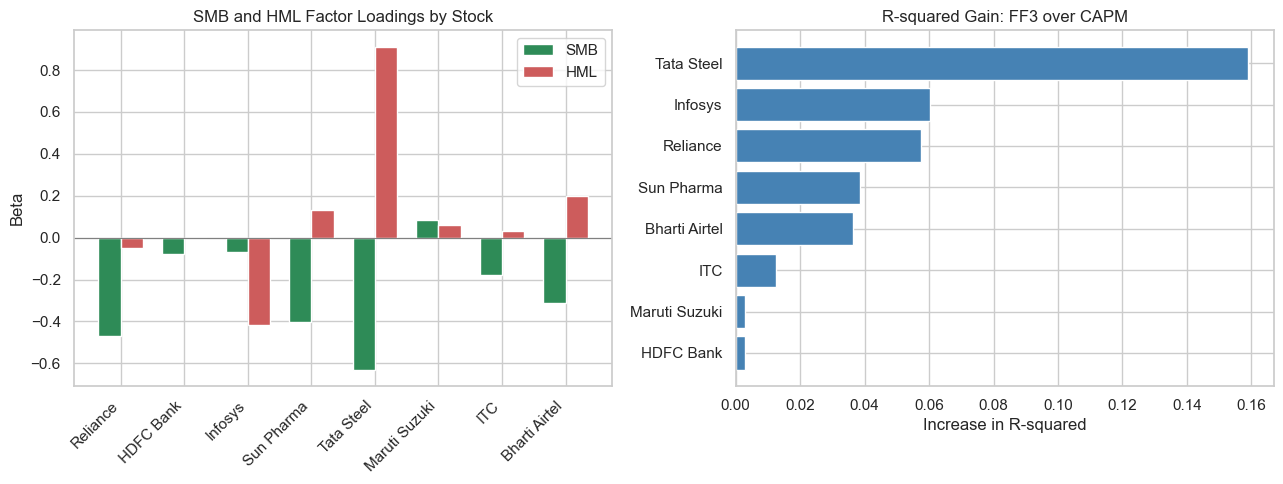

Average R-squared gain from adding SMB and HML: 0.0463

Stocks with significant SMB exposure (p < 0.05):
['Reliance', 'Sun Pharma', 'Tata Steel', 'Bharti Airtel']

Stocks with significant HML exposure (p < 0.05):
['Infosys', 'Tata Steel']


In [14]:
# Cell 14 — Phase 4: Fama-French 3-Factor Model | Factor Loadings & Explanatory Power Gain

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(ff3_summary.index))
width = 0.35

axes[0].bar(x - width/2, ff3_summary['Beta (SMB)'], width, label='SMB', color='seagreen')
axes[0].bar(x + width/2, ff3_summary['Beta (HML)'], width, label='HML', color='indianred')
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ff3_summary.index, rotation=45, ha='right')
axes[0].set_title('SMB and HML Factor Loadings by Stock')
axes[0].set_ylabel('Beta')
axes[0].legend()

r2_gain = (ff3_summary['R-squared'] - capm_summary['R-squared']).sort_values()
axes[1].barh(r2_gain.index, r2_gain.values, color='steelblue')
axes[1].set_title('R-squared Gain: FF3 over CAPM')
axes[1].set_xlabel('Increase in R-squared')

plt.tight_layout()
plt.show()

print("Average R-squared gain from adding SMB and HML:", round(r2_gain.mean(), 4))
print("\nStocks with significant SMB exposure (p < 0.05):")
print(ff3_summary[ff3_summary['SMB p-value'] < 0.05].index.tolist())
print("\nStocks with significant HML exposure (p < 0.05):")
print(ff3_summary[ff3_summary['HML p-value'] < 0.05].index.tolist())

# phase 5

In [15]:
# Cell 15 — Phase 5: Regression Assumption Testing | VIF - Multicollinearity Check

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(factors[['MF', 'SMB', 'HML']])

vif_data = pd.DataFrame({
    'Factor': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif_data = vif_data[vif_data['Factor'] != 'const'].reset_index(drop=True)
display(vif_data)

,Factor,VIF
0,MF,1.4161
1,SMB,1.1687
2,HML,1.3121


In [16]:
# Cell 16 — Phase 5: Regression Assumption Testing | White's Test for Heteroskedasticity

from statsmodels.stats.diagnostic import het_white

white_results = []

for stock in excess_returns.columns:
    model = ff3_models[stock]
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_white(model.resid, model.model.exog)

    white_results.append({
        'Stock': stock,
        'LM Statistic': lm_stat,
        'LM p-value': lm_pvalue,
        'F Statistic': f_stat,
        'F p-value': f_pvalue,
        'Heteroskedastic (5%)': 'Yes' if lm_pvalue < 0.05 else 'No'
    })

white_summary = pd.DataFrame(white_results).set_index('Stock')
display(white_summary.round(4))

,LM Statistic,LM p-value,F Statistic,F p-value,Heteroskedastic (5%)
Stock,,,,,
Reliance,25.8127,0.0022,3.2992,0.0012,Yes
HDFC Bank,22.3289,0.0079,2.7625,0.0057,Yes
Infosys,13.5197,0.1405,1.5472,0.1391,No
Sun Pharma,13.7165,0.1328,1.5723,0.1310,No
Tata Steel,18.4483,0.0303,2.2037,0.0262,Yes
Maruti Suzuki,23.3429,0.0055,2.9151,0.0037,Yes
ITC,17.0614,0.0478,2.0132,0.0433,Yes
Bharti Airtel,11.2468,0.2592,1.2627,0.2642,No


In [17]:
# Cell 17 — Phase 5: Regression Assumption Testing | Durbin-Watson Test for Autocorrelation

from statsmodels.stats.stattools import durbin_watson

dw_results = []

for stock in excess_returns.columns:
    model = ff3_models[stock]
    dw_stat = durbin_watson(model.resid)

    if dw_stat < 1.5:
        flag = 'Positive Autocorrelation'
    elif dw_stat > 2.5:
        flag = 'Negative Autocorrelation'
    else:
        flag = 'No Strong Autocorrelation'

    dw_results.append({
        'Stock': stock,
        'Durbin-Watson': dw_stat,
        'Flag': flag
    })

dw_summary = pd.DataFrame(dw_results).set_index('Stock')
display(dw_summary.round(4))

,Durbin-Watson,Flag
Stock,,
Reliance,2.0546,No Strong Autocorrelation
HDFC Bank,2.2669,No Strong Autocorrelation
Infosys,1.8317,No Strong Autocorrelation
Sun Pharma,2.2182,No Strong Autocorrelation
Tata Steel,1.9760,No Strong Autocorrelation
Maruti Suzuki,1.9507,No Strong Autocorrelation
ITC,1.9253,No Strong Autocorrelation
Bharti Airtel,2.0071,No Strong Autocorrelation


In [18]:
# Cell 17 — Phase 5: Regression Assumption Testing | Durbin-Watson Test for Autocorrelation

from statsmodels.stats.stattools import durbin_watson

dw_results = []

for stock in excess_returns.columns:
    model = ff3_models[stock]
    dw_stat = durbin_watson(model.resid)

    if dw_stat < 1.5:
        flag = 'Positive Autocorrelation'
    elif dw_stat > 2.5:
        flag = 'Negative Autocorrelation'
    else:
        flag = 'No Strong Autocorrelation'

    dw_results.append({
        'Stock': stock,
        'Durbin-Watson': dw_stat,
        'Flag': flag
    })

dw_summary = pd.DataFrame(dw_results).set_index('Stock')
display(dw_summary.round(4))

,Durbin-Watson,Flag
Stock,,
Reliance,2.0546,No Strong Autocorrelation
HDFC Bank,2.2669,No Strong Autocorrelation
Infosys,1.8317,No Strong Autocorrelation
Sun Pharma,2.2182,No Strong Autocorrelation
Tata Steel,1.9760,No Strong Autocorrelation
Maruti Suzuki,1.9507,No Strong Autocorrelation
ITC,1.9253,No Strong Autocorrelation
Bharti Airtel,2.0071,No Strong Autocorrelation


In [19]:
# Cell 18 — Phase 5: Regression Assumption Testing | Jarque-Bera Test for Residual Normality

from statsmodels.stats.stattools import jarque_bera

jb_results = []

for stock in excess_returns.columns:
    model = ff3_models[stock]
    jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(model.resid)

    jb_results.append({
        'Stock': stock,
        'JB Statistic': jb_stat,
        'JB p-value': jb_pvalue,
        'Skewness': skew,
        'Kurtosis': kurtosis,
        'Normal Residuals (5%)': 'Yes' if jb_pvalue >= 0.05 else 'No'
    })

jb_summary = pd.DataFrame(jb_results).set_index('Stock')
display(jb_summary.round(4))

,JB Statistic,JB p-value,Skewness,Kurtosis,Normal Residuals (5%)
Stock,,,,,
Reliance,2.1326,0.3443,0.2582,3.3523,Yes
HDFC Bank,18.2877,0.0001,-0.2718,4.7478,No
Infosys,17.0524,0.0002,-0.0622,4.7631,No
Sun Pharma,2.1477,0.3417,0.0779,3.6076,Yes
Tata Steel,4.6239,0.0991,0.0964,3.9000,Yes
Maruti Suzuki,1.2335,0.5397,0.2320,2.8965,Yes
ITC,4.8547,0.0883,0.0047,3.9430,Yes
Bharti Airtel,4.8406,0.0889,0.1463,3.8951,Yes


In [20]:
# Cell 19 — Phase 5: Regression Assumption Testing | Newey-West HAC Standard Errors

nw_lags = int(4 * (len(excess_returns) / 100) ** (2/9))

ff3_nw_models = {}
nw_comparison = []

X = sm.add_constant(factors[['MF', 'SMB', 'HML']])

for stock in excess_returns.columns:
    y = excess_returns[stock]
    model_nw = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lags})
    ff3_nw_models[stock] = model_nw
    original = ff3_models[stock]

    nw_comparison.append({
        'Stock': stock,
        'Beta (Mkt) SE - OLS': original.bse['MF'],
        'Beta (Mkt) SE - NW': model_nw.bse['MF'],
        'SMB p-value - OLS': original.pvalues['SMB'],
        'SMB p-value - NW': model_nw.pvalues['SMB'],
        'HML p-value - OLS': original.pvalues['HML'],
        'HML p-value - NW': model_nw.pvalues['HML'],
    })

nw_summary = pd.DataFrame(nw_comparison).set_index('Stock')
display(nw_summary.round(4))
print(f"\nNewey-West lag length used: {nw_lags}")

,Beta (Mkt) SE - OLS,Beta (Mkt) SE - NW,SMB p-value - OLS,SMB p-value - NW,HML p-value - OLS,HML p-value - NW
Stock,,,,,,
Reliance,0.1306,0.1661,0.0005,0.0000,0.6939,0.7360
HDFC Bank,0.1096,0.1420,0.4699,0.4948,0.9729,0.9801
Infosys,0.1404,0.1705,0.6255,0.6130,0.0028,0.0011
Sun Pharma,0.1651,0.1573,0.0160,0.0057,0.4178,0.3854
Tata Steel,0.1783,0.1709,0.0006,0.0007,0.0000,0.0000
Maruti Suzuki,0.1553,0.2450,0.5863,0.5773,0.6867,0.7244
ITC,0.1176,0.0994,0.1349,0.0732,0.7797,0.8396
Bharti Airtel,0.1409,0.1541,0.0273,0.0239,0.1498,0.1863



Newey-West lag length used: 4


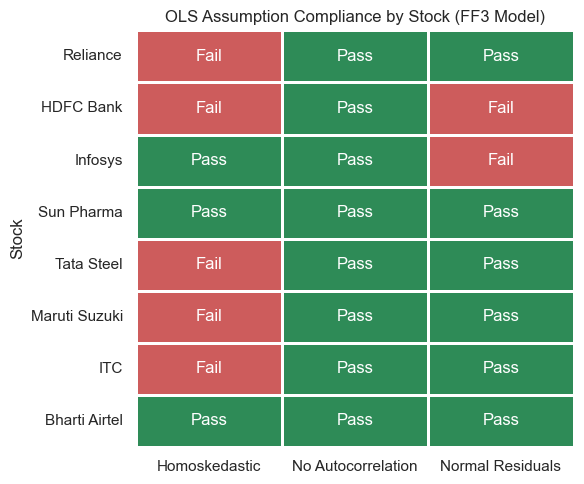

,Homoskedastic,No Autocorrelation,Normal Residuals
Stock,,,
Reliance,Fail,Pass,Pass
HDFC Bank,Fail,Pass,Fail
Infosys,Pass,Pass,Fail
Sun Pharma,Pass,Pass,Pass
Tata Steel,Fail,Pass,Pass
Maruti Suzuki,Fail,Pass,Pass
ITC,Fail,Pass,Pass
Bharti Airtel,Pass,Pass,Pass


Multicollinearity (VIF): Pass for all 8 stocks (shared regressor matrix, max VIF = 1.42)
Newey-West HAC applied to all stocks given the heteroskedasticity found above

Stocks passing all three per-stock diagnostics cleanly: ['Sun Pharma', 'Bharti Airtel']


In [21]:
# Cell 20 — Phase 5: Regression Assumption Testing | Diagnostic Summary Dashboard

from matplotlib.colors import ListedColormap

diagnostic_summary = pd.DataFrame({
    'Homoskedastic': white_summary['Heteroskedastic (5%)'].map({'Yes': 'Fail', 'No': 'Pass'}),
    'No Autocorrelation': dw_summary['Flag'].apply(lambda x: 'Pass' if x == 'No Strong Autocorrelation' else 'Fail'),
    'Normal Residuals': jb_summary['Normal Residuals (5%)'].map({'Yes': 'Pass', 'No': 'Fail'})
})

pass_matrix = (diagnostic_summary == 'Pass').astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pass_matrix, annot=diagnostic_summary.values, fmt='',
            cmap=ListedColormap(['indianred', 'seagreen']),
            cbar=False, linewidths=1, linecolor='white', ax=ax)
ax.set_title('OLS Assumption Compliance by Stock (FF3 Model)')
plt.tight_layout()
plt.show()

display(diagnostic_summary)

clean_stocks = diagnostic_summary[(diagnostic_summary == 'Pass').all(axis=1)].index.tolist()
print("Multicollinearity (VIF): Pass for all 8 stocks (shared regressor matrix, max VIF = 1.42)")
print("Newey-West HAC applied to all stocks given the heteroskedasticity found above")
print(f"\nStocks passing all three per-stock diagnostics cleanly: {clean_stocks}")

In [22]:
# Cell 21 — Phase 6: Rolling Window Regression | Compute Rolling FF3 Betas

window = 36
rolling_results = {}

X_full = sm.add_constant(factors[['MF', 'SMB', 'HML']])

for stock in excess_returns.columns:
    y = excess_returns[stock]

    dates, alphas, beta_mkt, beta_smb, beta_hml = [], [], [], [], []

    for i in range(window, len(y) + 1):
        y_window = y.iloc[i - window:i]
        X_window = X_full.iloc[i - window:i]
        model = sm.OLS(y_window, X_window).fit()

        dates.append(y.index[i - 1])
        alphas.append(model.params['const'])
        beta_mkt.append(model.params['MF'])
        beta_smb.append(model.params['SMB'])
        beta_hml.append(model.params['HML'])

    rolling_results[stock] = pd.DataFrame({
        'Alpha': alphas,
        'Beta_Mkt': beta_mkt,
        'Beta_SMB': beta_smb,
        'Beta_HML': beta_hml
    }, index=dates)

print(f"Rolling window: {window} months")
print(f"Rolling windows per stock: {len(rolling_results['Reliance'])}")
print(f"First window ends: {rolling_results['Reliance'].index[0].date()}")
print(f"Last window ends: {rolling_results['Reliance'].index[-1].date()}")
rolling_results['Reliance'].head()

Rolling window: 36 months
Rolling windows per stock: 96
First window ends: 2018-01-31
Last window ends: 2025-12-31


,Alpha,Beta_Mkt,Beta_SMB,Beta_HML
2018-01-31,0.0144,1.1339,-0.2596,-0.0378
2018-02-28,0.0176,1.1549,-0.2787,-0.0681
2018-03-31,0.0169,1.1758,-0.2594,-0.0608
2018-04-30,0.0151,1.2846,-0.3057,-0.1320
2018-05-31,0.0157,1.3634,-0.2964,-0.1994


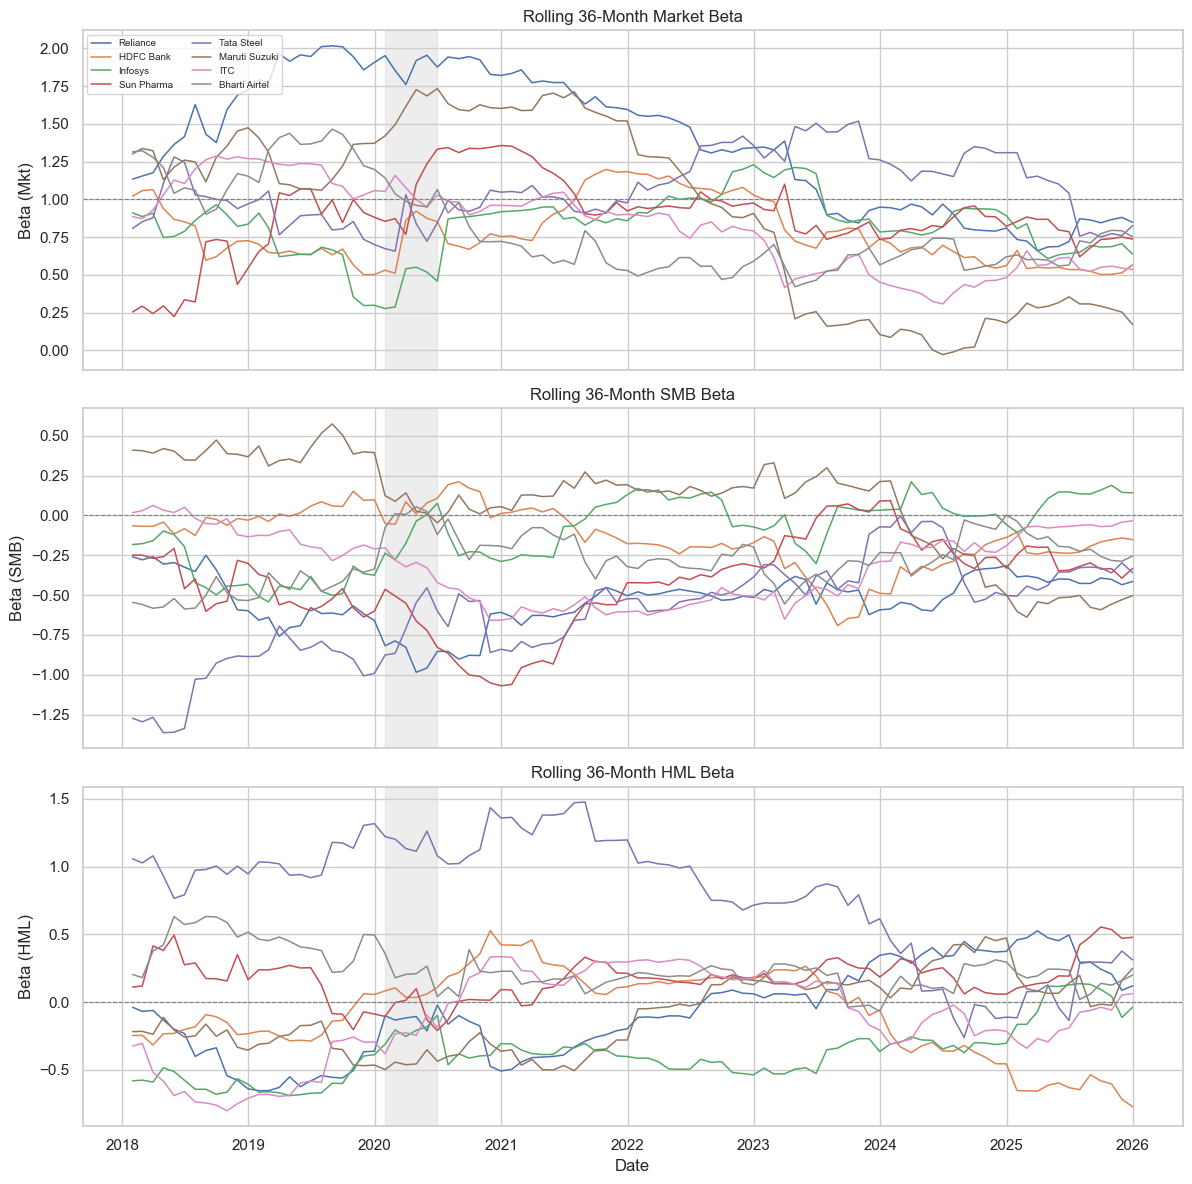

In [23]:
# Cell 22 — Phase 6: Rolling Window Regression | Rolling Beta Visualization

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for stock in excess_returns.columns:
    axes[0].plot(rolling_results[stock].index, rolling_results[stock]['Beta_Mkt'], label=stock, linewidth=1.1)
    axes[1].plot(rolling_results[stock].index, rolling_results[stock]['Beta_SMB'], label=stock, linewidth=1.1)
    axes[2].plot(rolling_results[stock].index, rolling_results[stock]['Beta_HML'], label=stock, linewidth=1.1)

for ax in axes:
    ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-30'), color='lightgray', alpha=0.4)

axes[0].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_title('Rolling 36-Month Market Beta')
axes[0].set_ylabel('Beta (Mkt)')
axes[0].legend(loc='upper left', fontsize=7, ncol=2)

axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Rolling 36-Month SMB Beta')
axes[1].set_ylabel('Beta (SMB)')

axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[2].set_title('Rolling 36-Month HML Beta')
axes[2].set_ylabel('Beta (HML)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [24]:
# Cell 23 — Phase 6: Rolling Window Regression | Beta Stability Summary

stability_results = []

for stock in excess_returns.columns:
    r = rolling_results[stock]
    stability_results.append({
        'Stock': stock,
        'Static Beta (FF3)': ff3_summary.loc[stock, 'Beta (Mkt)'],
        'Rolling Beta Mean': r['Beta_Mkt'].mean(),
        'Rolling Beta Std': r['Beta_Mkt'].std(),
        'Rolling Beta Min': r['Beta_Mkt'].min(),
        'Rolling Beta Max': r['Beta_Mkt'].max(),
        'Beta Range': r['Beta_Mkt'].max() - r['Beta_Mkt'].min()
    })

stability_summary = pd.DataFrame(stability_results).set_index('Stock').sort_values('Rolling Beta Std', ascending=False)
display(stability_summary.round(4))

,Static Beta (FF3),Rolling Beta Mean,Rolling Beta Std,Rolling Beta Min,Rolling Beta Max,Beta Range
Stock,,,,,,
Maruti Suzuki,0.8598,0.9380,0.5938,-0.0277,1.7343,1.7619
Reliance,1.2430,1.3880,0.4351,0.6597,2.0163,1.3566
Bharti Airtel,0.8106,0.8046,0.2925,0.4213,1.4650,1.0436
ITC,0.7569,0.8240,0.2814,0.3078,1.2874,0.9796
Sun Pharma,0.8248,0.8819,0.2548,0.2246,1.3567,1.1321
Tata Steel,1.0158,1.0725,0.2217,0.6575,1.5180,0.8604
HDFC Bank,0.7886,0.7797,0.2068,0.5010,1.1984,0.6974
Infosys,0.8459,0.8268,0.2043,0.2773,1.2294,0.9521


In [25]:
# Cell 24 — Phase 7: CAPM vs FF3 vs Carhart 4-Factor Model Comparison | Run Carhart 4-Factor Regression

carhart_models = {}
carhart_results = []

X = sm.add_constant(factors[['MF', 'SMB', 'HML', 'WML']])

for stock in excess_returns.columns:
    y = excess_returns[stock]
    model = sm.OLS(y, X).fit()
    carhart_models[stock] = model

    carhart_results.append({
        'Stock': stock,
        'Alpha (Monthly)': model.params['const'],
        'Alpha (Annualized)': model.params['const'] * 12,
        'Alpha p-value': model.pvalues['const'],
        'Beta (Mkt)': model.params['MF'],
        'Beta (SMB)': model.params['SMB'],
        'Beta (HML)': model.params['HML'],
        'Beta (WML)': model.params['WML'],
        'WML p-value': model.pvalues['WML'],
        'R-squared': model.rsquared,
        'Adj. R-squared': model.rsquared_adj
    })

carhart_summary = pd.DataFrame(carhart_results).set_index('Stock')
display(carhart_summary.round(4))

,Alpha (Monthly),Alpha (Annualized),Alpha p-value,Beta (Mkt),Beta (SMB),Beta (HML),Beta (WML),WML p-value,R-squared,Adj. R-squared
Stock,,,,,,,,,,
Reliance,0.0066,0.0791,0.2326,1.2371,-0.4717,-0.0793,-0.0903,0.4953,0.4597,0.4425
HDFC Bank,0.0088,0.1056,0.0412,0.7575,-0.0984,-0.1597,-0.4806,0.0000,0.4476,0.4300
Infosys,0.0048,0.0579,0.4162,0.8507,-0.0656,-0.3913,0.0742,0.6023,0.2321,0.2077
Sun Pharma,-0.0050,-0.0599,0.4743,0.8321,-0.3979,0.1667,0.1126,0.5009,0.2221,0.1974
Tata Steel,0.0051,0.0613,0.4889,0.9887,-0.6461,0.7765,-0.4179,0.0195,0.4767,0.4601
Maruti Suzuki,0.0098,0.1179,0.1262,0.8343,0.0688,-0.0673,-0.3949,0.0111,0.3181,0.2965
ITC,0.0024,0.0285,0.6239,0.7373,-0.1886,-0.0664,-0.3031,0.0101,0.3357,0.3146
Bharti Airtel,0.0048,0.0578,0.4192,0.8098,-0.3144,0.1943,-0.0113,0.9369,0.2911,0.2685


In [26]:
# Cell 25 — Phase 7: CAPM vs FF3 vs Carhart 4-Factor Model Comparison | Consolidated Comparison Table

model_comparison = pd.DataFrame({
    'CAPM R2': capm_summary['R-squared'],
    'FF3 R2': ff3_summary['R-squared'],
    'Carhart R2': carhart_summary['R-squared'],
    'FF3 Adj R2': ff3_summary['Adj. R-squared'],
    'Carhart Adj R2': carhart_summary['Adj. R-squared'],
    'CAPM Alpha (Ann)': capm_summary['Alpha (Annualized)'],
    'FF3 Alpha (Ann)': ff3_summary['Alpha (Annualized)'],
    'Carhart Alpha (Ann)': carhart_summary['Alpha (Annualized)'],
})

display(model_comparison.round(4))

,CAPM R2,FF3 R2,Carhart R2,FF3 Adj R2,Carhart Adj R2,CAPM Alpha (Ann),FF3 Alpha (Ann),Carhart Alpha (Ann)
Stock,,,,,,,,
Reliance,0.4001,0.4577,0.4597,0.4449,0.4425,0.0773,0.0639,0.0791
HDFC Bank,0.3482,0.3510,0.4476,0.3357,0.4300,0.0268,0.0242,0.1056
Infosys,0.1702,0.2305,0.2321,0.2123,0.2077,0.0460,0.0705,0.0579
Sun Pharma,0.1806,0.2193,0.2221,0.2008,0.1974,-0.0181,-0.0408,-0.0599
Tata Steel,0.2944,0.4535,0.4767,0.4406,0.4601,0.0720,-0.0094,0.0613
Maruti Suzuki,0.2793,0.2822,0.3181,0.2652,0.2965,0.0520,0.0511,0.1179
ITC,0.2871,0.2997,0.3357,0.2832,0.3146,-0.0144,-0.0228,0.0285
Bharti Airtel,0.2547,0.2910,0.2911,0.2743,0.2685,0.0799,0.0559,0.0578


In [27]:
# Cell 26 — Phase 7: CAPM vs FF3 vs Carhart 4-Factor Model Comparison | Nested F-Tests

from scipy import stats

f_test_results = []

for stock in excess_returns.columns:
    m_capm = capm_models[stock]
    m_ff3 = ff3_models[stock]
    m_carhart = carhart_models[stock]

    # CAPM -> FF3: joint significance of SMB and HML (q=2)
    q1 = m_ff3.df_model - m_capm.df_model
    f1 = ((m_capm.ssr - m_ff3.ssr) / q1) / (m_ff3.ssr / m_ff3.df_resid)
    p1 = stats.f.sf(f1, q1, m_ff3.df_resid)

    # FF3 -> Carhart: significance of WML (q=1)
    q2 = m_carhart.df_model - m_ff3.df_model
    f2 = ((m_ff3.ssr - m_carhart.ssr) / q2) / (m_carhart.ssr / m_carhart.df_resid)
    p2 = stats.f.sf(f2, q2, m_carhart.df_resid)

    f_test_results.append({
        'Stock': stock,
        'F (CAPM->FF3)': f1,
        'p (CAPM->FF3)': p1,
        'Sig CAPM->FF3': 'Yes' if p1 < 0.05 else 'No',
        'F (FF3->Carhart)': f2,
        'p (FF3->Carhart)': p2,
        'Sig FF3->Carhart': 'Yes' if p2 < 0.05 else 'No'
    })

f_test_summary = pd.DataFrame(f_test_results).set_index('Stock')
display(f_test_summary.round(4))

,F (CAPM->FF3),p (CAPM->FF3),Sig CAPM->FF3,F (FF3->Carhart),p (FF3->Carhart),Sig FF3->Carhart
Stock,,,,,,
Reliance,6.7380,0.0017,Yes,0.4678,0.4953,No
HDFC Bank,0.2684,0.7650,No,22.0273,0.0000,Yes
Infosys,4.9730,0.0083,Yes,0.2728,0.6023,No
Sun Pharma,3.1450,0.0464,Yes,0.4556,0.5009,No
Tata Steel,18.4820,0.0000,Yes,5.5954,0.0195,Yes
Maruti Suzuki,0.2554,0.7750,No,6.6399,0.0111,Yes
ITC,1.1402,0.3230,No,6.8291,0.0101,Yes
Bharti Airtel,3.2493,0.0420,Yes,0.0063,0.9369,No


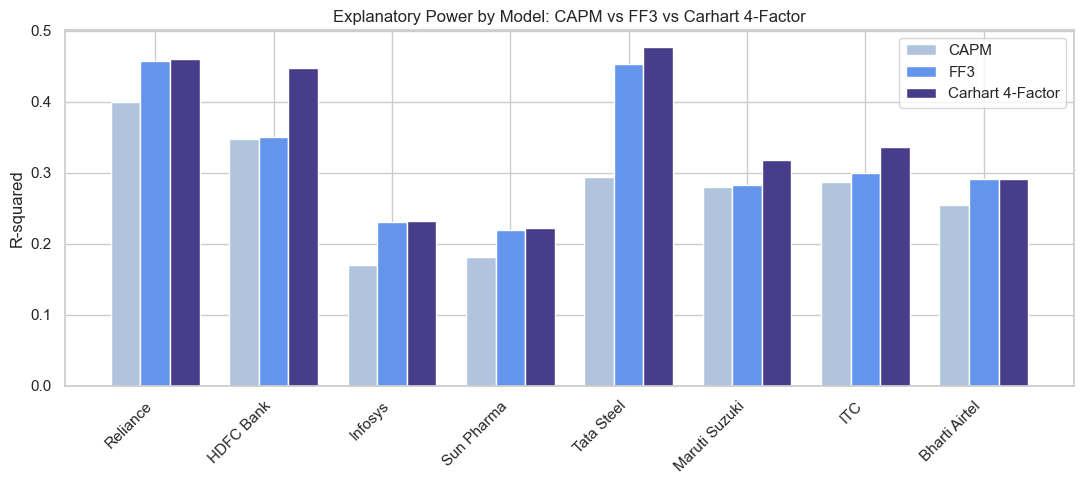

Stocks where FF3 significantly improves on CAPM: ['Reliance', 'Infosys', 'Sun Pharma', 'Tata Steel', 'Bharti Airtel']
Stocks where Carhart significantly improves on FF3: ['HDFC Bank', 'Tata Steel', 'Maruti Suzuki', 'ITC']

Stocks improved by BOTH steps: ['Tata Steel']


In [28]:
# Cell 27 — Phase 7: CAPM vs FF3 vs Carhart 4-Factor Model Comparison | R-squared Comparison Chart

fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(model_comparison.index))
width = 0.25

ax.bar(x - width, model_comparison['CAPM R2'], width, label='CAPM', color='lightsteelblue')
ax.bar(x, model_comparison['FF3 R2'], width, label='FF3', color='cornflowerblue')
ax.bar(x + width, model_comparison['Carhart R2'], width, label='Carhart 4-Factor', color='darkslateblue')

ax.set_xticks(x)
ax.set_xticklabels(model_comparison.index, rotation=45, ha='right')
ax.set_ylabel('R-squared')
ax.set_title('Explanatory Power by Model: CAPM vs FF3 vs Carhart 4-Factor')
ax.legend()

plt.tight_layout()
plt.show()

print("Stocks where FF3 significantly improves on CAPM:", f_test_summary[f_test_summary['Sig CAPM->FF3'] == 'Yes'].index.tolist())
print("Stocks where Carhart significantly improves on FF3:", f_test_summary[f_test_summary['Sig FF3->Carhart'] == 'Yes'].index.tolist())
print("\nStocks improved by BOTH steps:", f_test_summary[(f_test_summary['Sig CAPM->FF3'] == 'Yes') & (f_test_summary['Sig FF3->Carhart'] == 'Yes')].index.tolist())

# phase 8

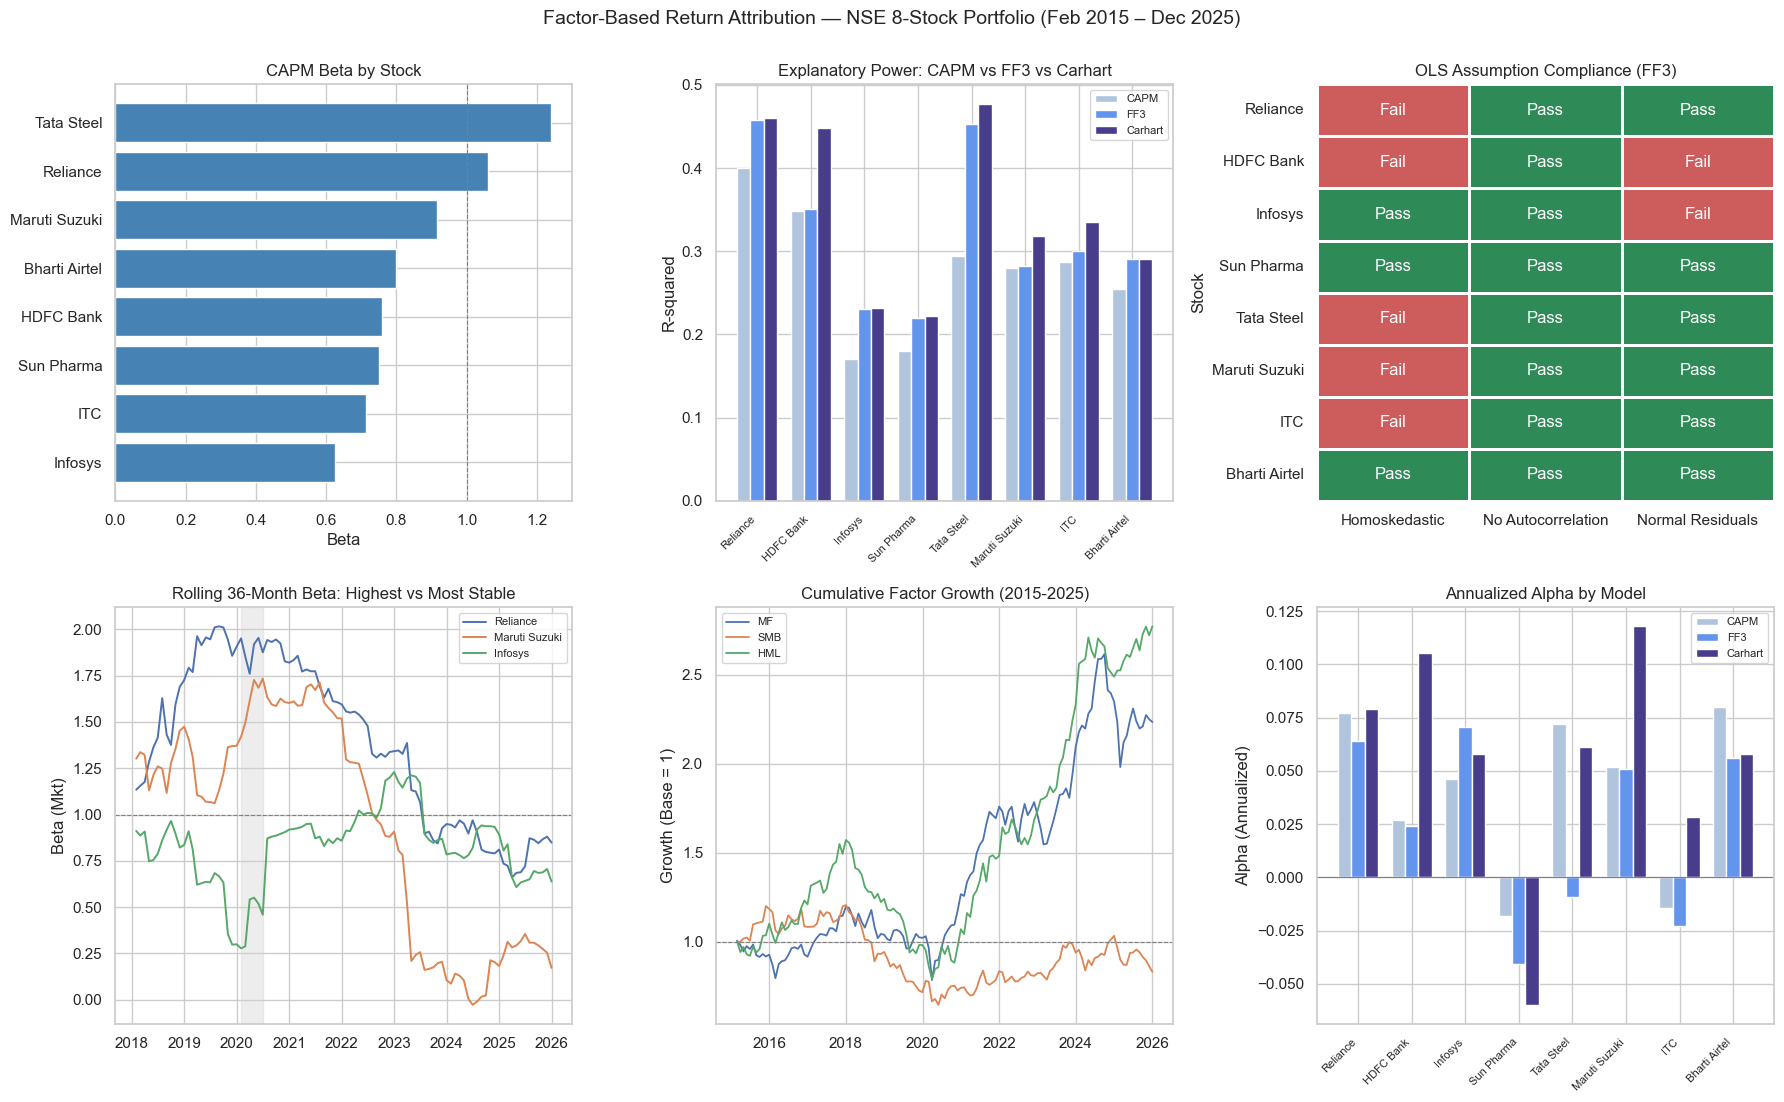

In [29]:
# Cell 28 — Phase 8: Final Dashboard | Six-Panel Project Summary Dashboard

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Panel 1: CAPM Beta by stock
sorted_beta = capm_summary['Beta'].sort_values()
axes[0, 0].barh(sorted_beta.index, sorted_beta.values, color='steelblue')
axes[0, 0].axvline(1, color='gray', linestyle='--', linewidth=0.8)
axes[0, 0].set_title('CAPM Beta by Stock')
axes[0, 0].set_xlabel('Beta')

# Panel 2: R-squared across all three models
x = np.arange(len(model_comparison.index))
width = 0.25
axes[0, 1].bar(x - width, model_comparison['CAPM R2'], width, label='CAPM', color='lightsteelblue')
axes[0, 1].bar(x, model_comparison['FF3 R2'], width, label='FF3', color='cornflowerblue')
axes[0, 1].bar(x + width, model_comparison['Carhart R2'], width, label='Carhart', color='darkslateblue')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(model_comparison.index, rotation=45, ha='right', fontsize=8)
axes[0, 1].set_title('Explanatory Power: CAPM vs FF3 vs Carhart')
axes[0, 1].set_ylabel('R-squared')
axes[0, 1].legend(fontsize=8)

# Panel 3: OLS assumption compliance heatmap
pass_matrix = (diagnostic_summary == 'Pass').astype(int)
sns.heatmap(pass_matrix, annot=diagnostic_summary.values, fmt='',
            cmap=ListedColormap(['indianred', 'seagreen']),
            cbar=False, linewidths=1, linecolor='white', ax=axes[0, 2])
axes[0, 2].set_title('OLS Assumption Compliance (FF3)')

# Panel 4: Rolling market beta - most and least stable stocks
highlight_stocks = ['Reliance', 'Maruti Suzuki', 'Infosys']
for stock in highlight_stocks:
    axes[1, 0].plot(rolling_results[stock].index, rolling_results[stock]['Beta_Mkt'],
                     label=stock, linewidth=1.4)
axes[1, 0].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[1, 0].axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-30'), color='lightgray', alpha=0.4)
axes[1, 0].set_title('Rolling 36-Month Beta: Highest vs Most Stable')
axes[1, 0].set_ylabel('Beta (Mkt)')
axes[1, 0].legend(fontsize=8)

# Panel 5: Cumulative factor growth
for col in ['MF', 'SMB', 'HML']:
    axes[1, 1].plot(cumulative_factors.index, cumulative_factors[col], label=col, linewidth=1.3)
axes[1, 1].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[1, 1].set_title('Cumulative Factor Growth (2015-2025)')
axes[1, 1].set_ylabel('Growth (Base = 1)')
axes[1, 1].legend(fontsize=8)

# Panel 6: Annualized alpha across models
axes[1, 2].bar(x - width, model_comparison['CAPM Alpha (Ann)'], width, label='CAPM', color='lightsteelblue')
axes[1, 2].bar(x, model_comparison['FF3 Alpha (Ann)'], width, label='FF3', color='cornflowerblue')
axes[1, 2].bar(x + width, model_comparison['Carhart Alpha (Ann)'], width, label='Carhart', color='darkslateblue')
axes[1, 2].axhline(0, color='gray', linewidth=0.8)
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(model_comparison.index, rotation=45, ha='right', fontsize=8)
axes[1, 2].set_title('Annualized Alpha by Model')
axes[1, 2].set_ylabel('Alpha (Annualized)')
axes[1, 2].legend(fontsize=8)

plt.suptitle('Factor-Based Return Attribution — NSE 8-Stock Portfolio (Feb 2015 – Dec 2025)', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()